# Syllable–Behavior Correlation Analysis

This notebook correlates MoSeq syllable usage with performance on a battery of behavioral assays to test whether kinematically-defined syllable clusters are functionally relevant to motor and cognitive outcomes.

**Behavioral assays:**
- **Rotarod** — motor coordination and endurance (latency to fall, speed at fall)
- **Wire hang** — grip strength and motor stamina (latency to fall)
- **Gridwalk** — forelimb motor precision (foot fault rate)
- **Y-maze** — spatial working memory (% spontaneous alternation)
- **NORT** (Novel Object Recognition Test) — recognition memory (discrimination index, preference ratio)
- **Open field / MoSeq dist-to-center** — thigmotaxis / anxiety-related locomotion

**Pipeline overview:**
1. Load and clean all behavioral datasets; standardize mouse IDs, timepoints, and treatment labels
2. Extract open field distance-to-center from the MoSeq frame-level dataframe
3. Merge all assays into a single per-animal per-timepoint dataframe
4. Cluster MoSeq syllables kinematically into four categories (motor/cognitive × deficit/improvement)
5. Compute per-animal per-timepoint syllable usage fractions
6. Run Spearman correlations between each syllable's usage and each behavioral metric; apply FDR correction
7. Visualize the correlation structure as a syllable × metric heatmap, annotated by cluster

In [ ]:
from google.colab.drive import mount
mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

rotarod_results = pd.read_csv('./ROTAROD_RESULTS.csv')
wire_results = pd.read_csv('./_Wire ANALYSIS REVISIONS 7 dpi 11.7.25 and 28 dpi 12.1.25 - all_results.csv')
gridwalk = pd.read_csv('./Gridwalk Counts.csv')
ymaze = pd.read_csv('./YMaze_Results.csv')
mapping = pd.read_csv('./mouse_list_mapping.csv')
nort = pd.read_csv('/mnt/g/Shared drives/llorente-lab/Moseq/AnalyzedData/Revision-NORT/analysis/nort_results.csv')
display(rotarod_results.head())
display(wire_results.head())
display(mapping.head())
display(gridwalk.head())
display(ymaze.head())
display(nort.head())

# 1. Data Loading

Load all behavioral assay result files and the mouse ID mapping table. The mapping table (`mouse_list_mapping.csv`) bridges between letter-based experiment IDs (e.g., `VK_20251026_a`) used in behavioral spreadsheets and the numeric MoSeq subject names used in `moseq_df`.

In [ ]:
import pandas as pd

moseq_df = pd.read_csv(
    "moseq_df.csv"
)

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (31,32) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


# 2. Open Field Metric from MoSeq

The MoSeq frame-level dataframe contains `dist_to_center_px` — the distance of the mouse centroid from the arena center on each frame. This serves as an open field proxy: lower values indicate more center exploration (less anxiety), higher values indicate more wall-hugging. Mean distance per animal per timepoint is used as the behavioral metric.

In [ ]:
oft_df = moseq_df[moseq_df['labels (usage sort)'] != -5]

# Aggregate: mean dist_to_center_px per mouse per timepoint
open_field_results = (
    oft_df.groupby(['SubjectName', 'timepoint', 'treatment', 'age', 'sex'])
    ['dist_to_center_px']
    .mean()
    .reset_index()
    .rename(columns={'dist_to_center_px': 'avg_dist_to_center_px'})
)

display(open_field_results.head())

,SubjectName,timepoint,treatment,age,sex,avg_dist_to_center_px
0,29109,30DPI,WMS,young,Male,124.264141
1,29109,7DPI,WMS,young,Male,115.781039
2,29109,BSL,WMS,young,Male,112.315042
3,29110,30DPI,WMS,young,Male,123.409455
4,29110,7DPI,WMS,young,Male,119.089502


In [ ]:
mouse_mapping = dict(
    zip(
        mapping['Experiment ID'],
        mapping['Mouse ID (t@l)'].astype(int)
    )
)

In [ ]:
wire_results['SubjectName'] = wire_results['Mouse'].map(mouse_mapping)

In [ ]:
rotarod_results['ExperimentID'] = (
    'VK_20251026_' + rotarod_results['Mouse'].astype(str)
)

rotarod_results['SubjectName'] = (
    rotarod_results['ExperimentID'].map(mouse_mapping)
)

In [ ]:
# ── Helper: extract letter suffix from Experiment ID ──────────────────────────
# VK_20251026_a -> 'a', VK_20251026_b -> 'b', etc.
def experiment_id_to_letter(eid):
    return eid.split('_')[-1].lower()

# Reverse mapping: letter -> full experiment ID
letter_to_exp_id = {experiment_id_to_letter(eid): eid for eid in mapping['Experiment ID']}

# ── Timepoint standardization ──────────────────────────────────────────────────
timepoint_map = {
    'BSL': 'BSL', 'Baseline': 'BSL', 'Baseline ': 'BSL',
    '7DPI': '7DPI', '7dpi': '7DPI',
    '21DPI': '30DPI', '21dpi': '30DPI',
    '30DPI': '30DPI', '30dpi': '30DPI',
}

# ── 1. ROTAROD ─────────────────────────────────────────────────────────────────
# Average latency to fall across 3 trials, map mouse letter -> experiment ID
rotarod_clean = rotarod_results.copy()
rotarod_clean['mouse_id'] = rotarod_clean['Mouse'].str.lower().map(letter_to_exp_id)
rotarod_clean['timepoint'] = rotarod_clean['Timepoint'].map(timepoint_map)

rotarod_clean['avg_latency_to_fall'] = rotarod_clean[
    ['Trial1_Latency_to_fall', 'Trial2_Latency_to_fall', 'Trial3_Latency_to_fall']
].mean(axis=1)
rotarod_clean['avg_speed_when_fall'] = rotarod_clean[
    ['Trial1_speed_when_fall', 'Trial2_speed_when_fall', 'Trial3_speed_when_fall']
].mean(axis=1)

rotarod_clean = rotarod_clean[['mouse_id', 'timepoint', 'Treatment', 'Bodyweight',
                                'avg_latency_to_fall', 'avg_speed_when_fall']].rename(
    columns={'Treatment': 'treatment'})

# ── 2. WIRE HANGING ────────────────────────────────────────────────────────────
# Wide -> long, use full experiment ID directly
wire_clean = wire_results.copy()
wire_clean['mouse_id'] = wire_clean['Mouse']  # already VK_20251026_x format

trial_cols = {
    'Trial1_BSL': ('BSL', 1), 'Trial2_BSL': ('BSL', 2), 'Trial3_BSL': ('BSL', 3),
    'Trial1_7DPI': ('7DPI', 1), 'Trial2_7DPI': ('7DPI', 2), 'Trial3_7DPI': ('7DPI', 3),
    'Trial1_30DPI': ('30DPI', 1), 'Trial2_30DPI': ('30DPI', 2), 'Trial3_30DPI': ('30DPI', 3),
}

wire_long = wire_clean.melt(
    id_vars=['mouse_id', 'Treatment'],
    value_vars=list(trial_cols.keys()),
    var_name='trial_col', value_name='latency'
)
wire_long['timepoint'] = wire_long['trial_col'].map(lambda x: trial_cols[x][0])

wire_clean = (wire_long.groupby(['mouse_id', 'timepoint', 'Treatment'])['latency']
              .mean().reset_index()
              .rename(columns={'latency': 'avg_wire_latency', 'Treatment': 'treatment'}))

# ── 3. GRIDWALK ────────────────────────────────────────────────────────────────
# Wide -> long, 'Mouse A' -> 'a' -> experiment ID
gridwalk_clean = gridwalk.copy()
gridwalk_clean['mouse_id'] = (gridwalk_clean['Mouse']
                               .str.replace('Mouse ', '', case=False)
                               .str.strip().str.lower()
                               .map(letter_to_exp_id))

gridwalk_long = gridwalk_clean.melt(
    id_vars=['mouse_id', 'Group'],
    value_vars=['Baseline ', '7DPI', '21DPI'],
    var_name='timepoint', value_name='foot_faults'
)
gridwalk_long['timepoint'] = gridwalk_long['timepoint'].map(timepoint_map)
gridwalk_clean = gridwalk_long.rename(columns={'Group': 'treatment'})

# ── 4. YMAZE ───────────────────────────────────────────────────────────────────
# Mouse ID is single letter, map to experiment ID
ymaze_clean = ymaze.copy()
ymaze_clean = ymaze_clean.dropna(subset=['Mouse ID'])
ymaze_clean['mouse_id'] = ymaze_clean['Mouse ID'].str.lower().map(letter_to_exp_id)
ymaze_clean['timepoint'] = ymaze_clean['Timepoint'].map(timepoint_map)
ymaze_clean = ymaze_clean[['mouse_id', 'timepoint', 'Group', '% Alternations', 'Total Entries']].rename(
    columns={'Group': 'treatment', '% Alternations': 'pct_alternations', 'Total Entries': 'total_entries'})

# ── 5. NORT ────────────────────────────────────────────────────────────────────
# Already clean, just standardize column names
nort_clean = nort[['mouse_id', 'timepoint', 'treatment',
                   'discrimination_index', 'preference_ratio']].copy()
nort_clean['timepoint'] = nort_clean['timepoint'].map(timepoint_map)

# ── 6. OPEN FIELD ──────────────────────────────────────────────────────────────
oft_clean = open_field_results.rename(columns={'SubjectName': 'mouse_id'}).copy()
oft_clean['timepoint'] = oft_clean['timepoint'].map(timepoint_map)

# ── Preview all cleaned dfs ────────────────────────────────────────────────────
for name, df in [('rotarod', rotarod_clean), ('wire', wire_clean),
                  ('gridwalk', gridwalk_clean), ('ymaze', ymaze_clean),
                  ('nort', nort_clean), ('open_field', oft_clean)]:
    print(f'\n── {name} ──')
    display(df.head(3))
    print('shape:', df.shape)


── rotarod ──


,mouse_id,timepoint,treatment,Bodyweight,avg_latency_to_fall,avg_speed_when_fall
0,VK_20251026_a,BSL,Control,28.83,300.0,40.000000
1,VK_20251026_b,BSL,Control,31.61,39.0,8.666667
2,VK_20251026_c,BSL,Control,29.17,300.0,40.000000


shape: (108, 6)

── wire ──


,mouse_id,timepoint,treatment,avg_wire_latency
0,VK_20251026_a,30DPI,Control,120.0
1,VK_20251026_a,7DPI,Control,120.0
2,VK_20251026_a,BSL,Control,120.0


shape: (108, 4)

── gridwalk ──


...

shape: (105, 5)

── nort ──


,mouse_id,timepoint,treatment,discrimination_index,preference_ratio
0,VK_20251026_a,BSL,Control,0.218742,0.609371
1,VK_20251026_e,BSL,Control,0.472135,0.736068
2,VK_20251026_b,BSL,Control,0.147059,0.573529


shape: (70, 5)

── open_field ──


,mouse_id,timepoint,treatment,age,sex,avg_dist_to_center_px
0,29109,30DPI,WMS,young,Male,124.264141
1,29109,7DPI,WMS,young,Male,115.781039
2,29109,BSL,WMS,young,Male,112.315042


shape: (562, 6)


# 3. Data Cleaning and Standardization

Standardize all datasets to a common schema before merging:
- **Mouse IDs**: map letter suffixes (e.g., `'a'`) or numeric IDs to full experiment IDs (e.g., `VK_20251026_a`)
- **Timepoints**: normalize variant spellings (`'Baseline'`, `'21DPI'`, etc.) to canonical labels (`'BSL'`, `'30DPI'`)
- **Treatment labels**: collapse `'CTRL'` / `'ctrl'` → `'Control'`
- **Rotarod**: average latency and speed across 3 trials per session
- **Wire hang**: reshape from wide (per-trial columns) to long format, then average trials
- **Gridwalk**: reshape from wide to long format
- **Y-maze / NORT**: drop rows with missing mouse IDs and remap to experiment IDs

In [ ]:
treatment_map = {'CTRL': 'Control', 'ctrl': 'Control'}
timepoint_map = {
    'BSL': 'BSL', 'Baseline': 'BSL', 'Baseline ': 'BSL',
    '7DPI': '7DPI', '7dpi': '7DPI',
    '21DPI': '30DPI', '21dpi': '30DPI',
    '30DPI': '30DPI', '30dpi': '30DPI',
}

# Build numeric ID -> experiment ID mapping
numeric_to_exp_id = dict(zip(mapping['Mouse ID (t@l)'].astype(int), mapping['Experiment ID']))

# Subset and map oft_clean to only mice in mapping
oft_clean = open_field_results.copy()
oft_clean['mouse_id'] = pd.to_numeric(oft_clean['SubjectName'], errors='coerce')
oft_clean = oft_clean.dropna(subset=['mouse_id'])
oft_clean['mouse_id'] = oft_clean['mouse_id'].astype(int).map(numeric_to_exp_id)
oft_clean = oft_clean.dropna(subset=['mouse_id'])

oft_clean = oft_clean.drop(columns=['SubjectName'])
oft_clean['timepoint'] = oft_clean['timepoint'].map(timepoint_map)
oft_clean['treatment'] = oft_clean['treatment'].replace(treatment_map)

print("shape:", oft_clean.shape)
display(oft_clean.head())

shape: (106, 6)


,timepoint,treatment,age,sex,avg_dist_to_center_px,mouse_id
0,30DPI,WMS,young,Male,124.264141,VK_20251026_ag
1,7DPI,WMS,young,Male,115.781039,VK_20251026_ag
2,BSL,WMS,young,Male,112.315042,VK_20251026_ag
3,30DPI,WMS,young,Male,123.409455,VK_20251026_ah
4,7DPI,WMS,young,Male,119.089502,VK_20251026_ah


In [ ]:
ymaze = pd.read_csv('./YMaze_Results.csv')

ymaze_clean = ymaze.copy()
ymaze_clean = ymaze_clean.dropna(subset=['Mouse ID'])
ymaze_clean['mouse_id'] = (ymaze['Mouse ID']
                            .str.strip()
                            .str.lower()
                            .map(letter_to_exp_id))
ymaze_clean['timepoint'] = ymaze_clean['Timepoint'].map(timepoint_map)
ymaze_clean['treatment'] = ymaze_clean['Group'].replace(treatment_map)
ymaze_clean = ymaze_clean[['mouse_id', 'timepoint', 'treatment', '% Alternations', 'Total Entries']].rename(
    columns={'% Alternations': 'pct_alternations', 'Total Entries': 'total_entries'})

print("Remaining NaNs:", ymaze_clean['mouse_id'].isna().sum())
print("shape:", ymaze_clean.shape)
display(ymaze_clean.head())

Remaining NaNs: 0
shape: (105, 5)


,mouse_id,timepoint,treatment,pct_alternations,total_entries
0,VK_20251026_a,BSL,Control,47.368421,59.0
1,VK_20251026_b,BSL,Control,64.583333,50.0
2,VK_20251026_c,BSL,Control,52.000000,52.0
3,VK_20251026_d,BSL,Control,45.098039,53.0
4,VK_20251026_e,BSL,Control,71.111111,47.0


In [ ]:
gridwalk_clean['treatment'] = gridwalk_clean['treatment'].replace({'CTRL': 'Control'})

# Verify
print(gridwalk_clean['treatment'].unique())

['Control' 'CS' 'WMS']


In [ ]:
from functools import reduce

# Add a source column to each df for debugging, then merge all on mouse_id + timepoint
dfs = [
    rotarod_clean.drop(columns=['Bodyweight'], errors='ignore'),
    wire_clean,
    gridwalk_clean,
    ymaze_clean,
    nort_clean,
    oft_clean.drop(columns=['age', 'sex'], errors='ignore'),  # these will come from moseq metadata
]

behavior_df = reduce(lambda l, r: pd.merge(l, r, on=['mouse_id', 'timepoint', 'treatment'], how='outer'), dfs)

# Add back metadata from oft_clean
meta = oft_clean[['mouse_id', 'timepoint', 'age', 'sex']].drop_duplicates()
behavior_df = behavior_df.merge(meta, on=['mouse_id', 'timepoint'], how='left')

print("shape:", behavior_df.shape)
print("NaN summary:\n", behavior_df.isna().sum())
display(behavior_df.head())

shape: (111, 14)
NaN summary:
 mouse_id                  0
timepoint                 0
treatment                 0
avg_latency_to_fall       5
avg_speed_when_fall       5
avg_wire_latency          4
foot_faults               4
pct_alternations          4
total_entries             4
discrimination_index     39
preference_ratio         39
avg_dist_to_center_px     3
age                       3
sex                       3
dtype: int64


,mouse_id,timepoint,treatment,avg_latency_to_fall,avg_speed_when_fall,avg_wire_latency,foot_faults,pct_alternations,total_entries,discrimination_index,preference_ratio,avg_dist_to_center_px,age,sex
0,VK_20251026_a,BSL,Control,300.000000,40.000000,120.0,12.10,47.368421,59.0,0.218742,0.609371,118.825724,young,Male
1,VK_20251026_b,BSL,Control,39.000000,8.666667,120.0,10.00,64.583333,50.0,0.147059,0.573529,129.598835,young,Male
2,VK_20251026_c,BSL,Control,300.000000,40.000000,120.0,15.38,52.000000,52.0,0.358005,0.679003,120.499539,young,Male
3,VK_20251026_d,BSL,Control,141.333333,20.666667,120.0,16.00,45.098039,53.0,-0.034812,0.482594,116.713391,young,Male
4,VK_20251026_e,BSL,Control,197.000000,27.333333,120.0,12.50,71.111111,47.0,0.472135,0.736068,119.785778,young,Male


# 4. Merge Behavioral Datasets

Outer-join all six cleaned assay dataframes on `(mouse_id, timepoint, treatment)` into a single `behavior_df`. An outer join is used to retain all animals even if they are missing data from one or more assays. The NaN summary printed below shows which assays have the most missing values (NORT has the fewest animals due to experimental design).

In [ ]:
moseq_df['SubjectName'] = (
    moseq_df['SubjectName'].astype(str)
)

In [ ]:
# Filter out initialization frames
moseq_clean = moseq_df[moseq_df['labels (usage sort)'] >= 0].copy()

# Compute mean velocity, mean displacement, and n per syllable
syllable_kinematics = (
    moseq_clean
    .groupby('labels (usage sort)')
    .agg(
        mean_velocity=('velocity_2d_mm', 'mean'),
        mean_displacement=('dist_to_center_px', 'mean'),
        n=('velocity_2d_mm', 'count')
    )
    .reset_index()
    .rename(columns={'labels (usage sort)': 'syllable'})
)

# Drop syllables with insufficient data BEFORE clustering
syllable_kinematics = syllable_kinematics[syllable_kinematics['n'] >= 5].reset_index(drop=True)

# Hierarchical split: first by displacement, then velocity within each group
disp_thresh = syllable_kinematics['mean_displacement'].quantile(0.5)
syllable_kinematics['disp_group'] = syllable_kinematics['mean_displacement'].apply(
    lambda x: 'high_disp' if x >= disp_thresh else 'low_disp'
)

def assign_cluster(grp):
    vel_thresh = grp['mean_velocity'].quantile(0.5)
    grp = grp.copy()
    grp['cluster'] = grp['mean_velocity'].apply(
        lambda x: 'high_vel' if x >= vel_thresh else 'low_vel'
    )
    grp['cluster'] = grp['disp_group'] + '_' + grp['cluster']
    return grp

syllable_kinematics = (
    syllable_kinematics
    .groupby('disp_group', group_keys=False)
    .apply(assign_cluster)
)

print(syllable_kinematics['cluster'].value_counts())
print("Total syllables:", len(syllable_kinematics))

low_disp_high_vel     12
high_disp_high_vel    12
low_disp_low_vel      12
high_disp_low_vel     12
Name: cluster, dtype: int64
Total syllables: 48


# 5. Syllable Kinematic Clustering

Cluster all MoSeq syllables (those with ≥5 frames) into four categories using a hierarchical median split on mean 2D velocity and mean distance-to-center (displacement proxy):

| Cluster | Displacement | Velocity | Behavioral interpretation |
|---|---|---|---|
| `high_disp_high_vel` | High | High | Motor-related improvement |
| `high_disp_low_vel` | High | Low | Motor-related deficit |
| `low_disp_high_vel` | Low | High | Cognitive-related improvement |
| `low_disp_low_vel` | Low | Low | Cognitive-related deficit |

# 6. Spearman Correlation Analysis

For each syllable × behavioral metric pair, compute the Spearman rank correlation between per-animal syllable usage fraction and the behavioral score, pooling across all timepoints. Pairs with fewer than 5 valid observations are skipped.

FDR correction (Benjamini-Hochberg) is applied separately within each behavioral metric to control the false discovery rate across syllables. Correlations with FDR-adjusted p < 0.05 are marked significant.

In [ ]:
from scipy.stats import spearmanr
!pip install statsmodels
from statsmodels.stats.multitest import multipletests
import numpy as np

# ── 1. Compute syllable usage per mouse per timepoint ─────────────────────────
moseq_clean = moseq_df[moseq_df['labels (usage sort)'] >= 0].copy()

usage_df = (
    moseq_clean
    .groupby(['SubjectName', 'timepoint', 'labels (usage sort)'])
    .size()
    .reset_index(name='n_frames')
)
usage_df['usage'] = (
    usage_df
    .groupby(['SubjectName', 'timepoint'])['n_frames']
    .transform(lambda x: x / x.sum())
)

# Map SubjectName (numeric) to experiment ID
usage_df['mouse_id'] = pd.to_numeric(usage_df['SubjectName'], errors='coerce')
usage_df['mouse_id'] = usage_df['mouse_id'].map(numeric_to_exp_id)
usage_df = usage_df.dropna(subset=['mouse_id'])
usage_df = usage_df.rename(columns={'labels (usage sort)': 'syllable'})

# ── 2. Merge with behavior_df ─────────────────────────────────────────────────
behavioral_cols = [
    'avg_latency_to_fall', 'avg_wire_latency', 'foot_faults',
    'pct_alternations', 'discrimination_index', 'avg_dist_to_center_px'
]

merged = usage_df.merge(
    behavior_df[['mouse_id', 'timepoint'] + behavioral_cols],
    on=['mouse_id', 'timepoint'],
    how='inner'
)

# ── 3. Spearman correlation: each syllable x each behavioral metric ────────────
results = []

for syllable, syl_grp in merged.groupby('syllable'):
    for metric in behavioral_cols:
        valid = syl_grp[['usage', metric]].dropna()
        if len(valid) < 5:
            continue
        rho, p = spearmanr(valid['usage'], valid[metric])
        results.append({
            'syllable': syllable,
            'metric': metric,
            'rho': rho,
            'pval': p,
            'n': len(valid)
        })

corr_df = pd.DataFrame(results)

# ── 4. FDR correction per metric ──────────────────────────────────────────────
corr_df['pval_fdr'] = np.nan

for metric, grp in corr_df.groupby('metric'):
    _, pvals_corrected, _, _ = multipletests(grp['pval'], method='fdr_bh')
    corr_df.loc[grp.index, 'pval_fdr'] = pvals_corrected

corr_df['significant'] = corr_df['pval_fdr'] < 0.05

# ── 5. Merge in cluster labels (only syllables that passed n>=5) ──────────────
corr_df = corr_df.merge(syllable_kinematics[['syllable', 'cluster']], on='syllable', how='inner')

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


shape: (240, 8)

Cluster counts:
high_disp_low_vel     72
high_disp_high_vel    72
low_disp_high_vel     60
low_disp_low_vel      36
Name: cluster, dtype: int64

Significant correlations: 26


/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


,syllable,metric,rho,pval,n,pval_fdr,significant,cluster
44,7,foot_faults,0.435873,0.000003,107,0.000086,True,low_disp_low_vel
74,12,foot_faults,0.429624,0.000004,106,0.000086,True,low_disp_high_vel
62,10,foot_faults,0.375145,0.000069,107,0.000548,True,low_disp_low_vel
155,25,avg_dist_to_center_px,0.363428,0.000111,108,0.004426,True,high_disp_high_vel
164,27,foot_faults,0.345011,0.000383,102,0.002191,True,low_disp_low_vel
218,36,foot_faults,0.330334,0.000511,107,0.002555,True,low_disp_low_vel
186,31,avg_latency_to_fall,0.326949,0.000624,106,0.012490,True,low_disp_low_vel
206,34,foot_faults,0.322795,0.000883,103,0.003209,True,low_disp_high_vel
158,26,foot_faults,0.305612,0.001369,107,0.003713,True,high_disp_low_vel
80,13,foot_faults,0.260661,0.006962,106,0.015834,True,low_disp_high_vel


In [ ]:
print("Syllables in syllable_kinematics:", sorted(syllable_kinematics['syllable'].tolist()))
print("Syllables in corr_df:", sorted(corr_df['syllable'].unique().tolist()))
print("Missing from corr_df:", set(syllable_kinematics['syllable']) - set(corr_df['syllable']))

Syllables in syllable_kinematics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
Syllables in corr_df: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 41, 42]
Missing from corr_df: {38, 39, 40, 43, 44, 45, 46, 47}


### QC: Syllable Coverage Check

Verify that all syllables present in the kinematic clustering table are also represented in the correlation results. Syllables missing from `corr_df` were dropped because fewer than 5 animals had valid usage + behavioral data for that syllable. The clustering will be recomputed on only the surviving syllables to ensure balanced cluster sizes.

In [ ]:
# Recompute kinematics only for syllables that survived the correlation filter
valid_syllables = corr_df['syllable'].unique()

syllable_kinematics = (
    moseq_clean
    .groupby('labels (usage sort)')
    .agg(
        mean_velocity=('velocity_2d_mm', 'mean'),
        mean_displacement=('dist_to_center_px', 'mean'),
        n=('velocity_2d_mm', 'count')
    )
    .reset_index()
    .rename(columns={'labels (usage sort)': 'syllable'})
)

# Keep only valid syllables
syllable_kinematics = syllable_kinematics[
    syllable_kinematics['syllable'].isin(valid_syllables)
].reset_index(drop=True)

# Hierarchical clustering on the filtered set
disp_thresh = syllable_kinematics['mean_displacement'].quantile(0.5)
syllable_kinematics['disp_group'] = syllable_kinematics['mean_displacement'].apply(
    lambda x: 'high_disp' if x >= disp_thresh else 'low_disp'
)

def assign_cluster(grp):
    vel_thresh = grp['mean_velocity'].quantile(0.5)
    grp = grp.copy()
    grp['cluster'] = grp['mean_velocity'].apply(
        lambda x: 'high_vel' if x >= vel_thresh else 'low_vel'
    )
    grp['cluster'] = grp['disp_group'] + '_' + grp['cluster']
    return grp

syllable_kinematics = (
    syllable_kinematics
    .groupby('disp_group', group_keys=False)
    .apply(assign_cluster)
)

# Re-merge cluster labels into corr_df
corr_df = corr_df.drop(columns=['cluster']).merge(
    syllable_kinematics[['syllable', 'cluster']], on='syllable', how='inner'
)

print(corr_df['cluster'].value_counts())
print("Total syllables:", corr_df['syllable'].nunique())

low_disp_low_vel      60
low_disp_high_vel     60
high_disp_low_vel     60
high_disp_high_vel    60
Name: cluster, dtype: int64
Total syllables: 40


### Re-cluster on Valid Syllables Only

Re-run the kinematic clustering using only syllables that survived the correlation filter (those with sufficient behavioral data). This ensures the cluster assignments used for visualization are based on the same syllable set as the correlation results, and that each cluster has equal size.

In [ ]:
syllable_order = (
    corr_df[['syllable', 'cluster']]
    .drop_duplicates()
    .sort_values(['cluster', 'syllable'])
    ['syllable']
    .tolist()
)

syllable_clusters = (
    corr_df[['syllable', 'cluster']]
    .drop_duplicates()
    .set_index('syllable')
    ['cluster']
    .loc[syllable_order]
)

rho_matrix = corr_df.pivot(index='syllable', columns='metric', values='rho').loc[syllable_order]
sig_matrix = corr_df.pivot(index='syllable', columns='metric', values='significant').loc[syllable_order]

# 7. Visualization

## 7.1 Syllable × Metric Correlation Heatmap

Plot a heatmap of Spearman ρ for all syllable × behavioral metric pairs. Syllables are sorted by cluster (rows), and metrics are grouped into motor tests (rotarod, wire hang, gridwalk — orange column strip) and cognitive tests (NORT, Y-maze, open field — blue column strip). Significant pairs (FDR < 0.05) are marked with `*`. A color strip on the left annotates each syllable's kinematic cluster.

In [ ]:
cluster_colors = {
    'low_disp_low_vel':   '#87CEEB',  # Sky Blue
    'low_disp_high_vel':  '#4169E1',  # Royal Blue
    'high_disp_low_vel':  '#FA8072',  # Salmon
    'high_disp_high_vel': '#DC143C',  # Crimson
}
syllable_clusters = (
    syllable_kinematics
    .set_index('syllable')
    .loc[syllable_order, 'cluster']
)

row_colors = syllable_clusters.map(cluster_colors)

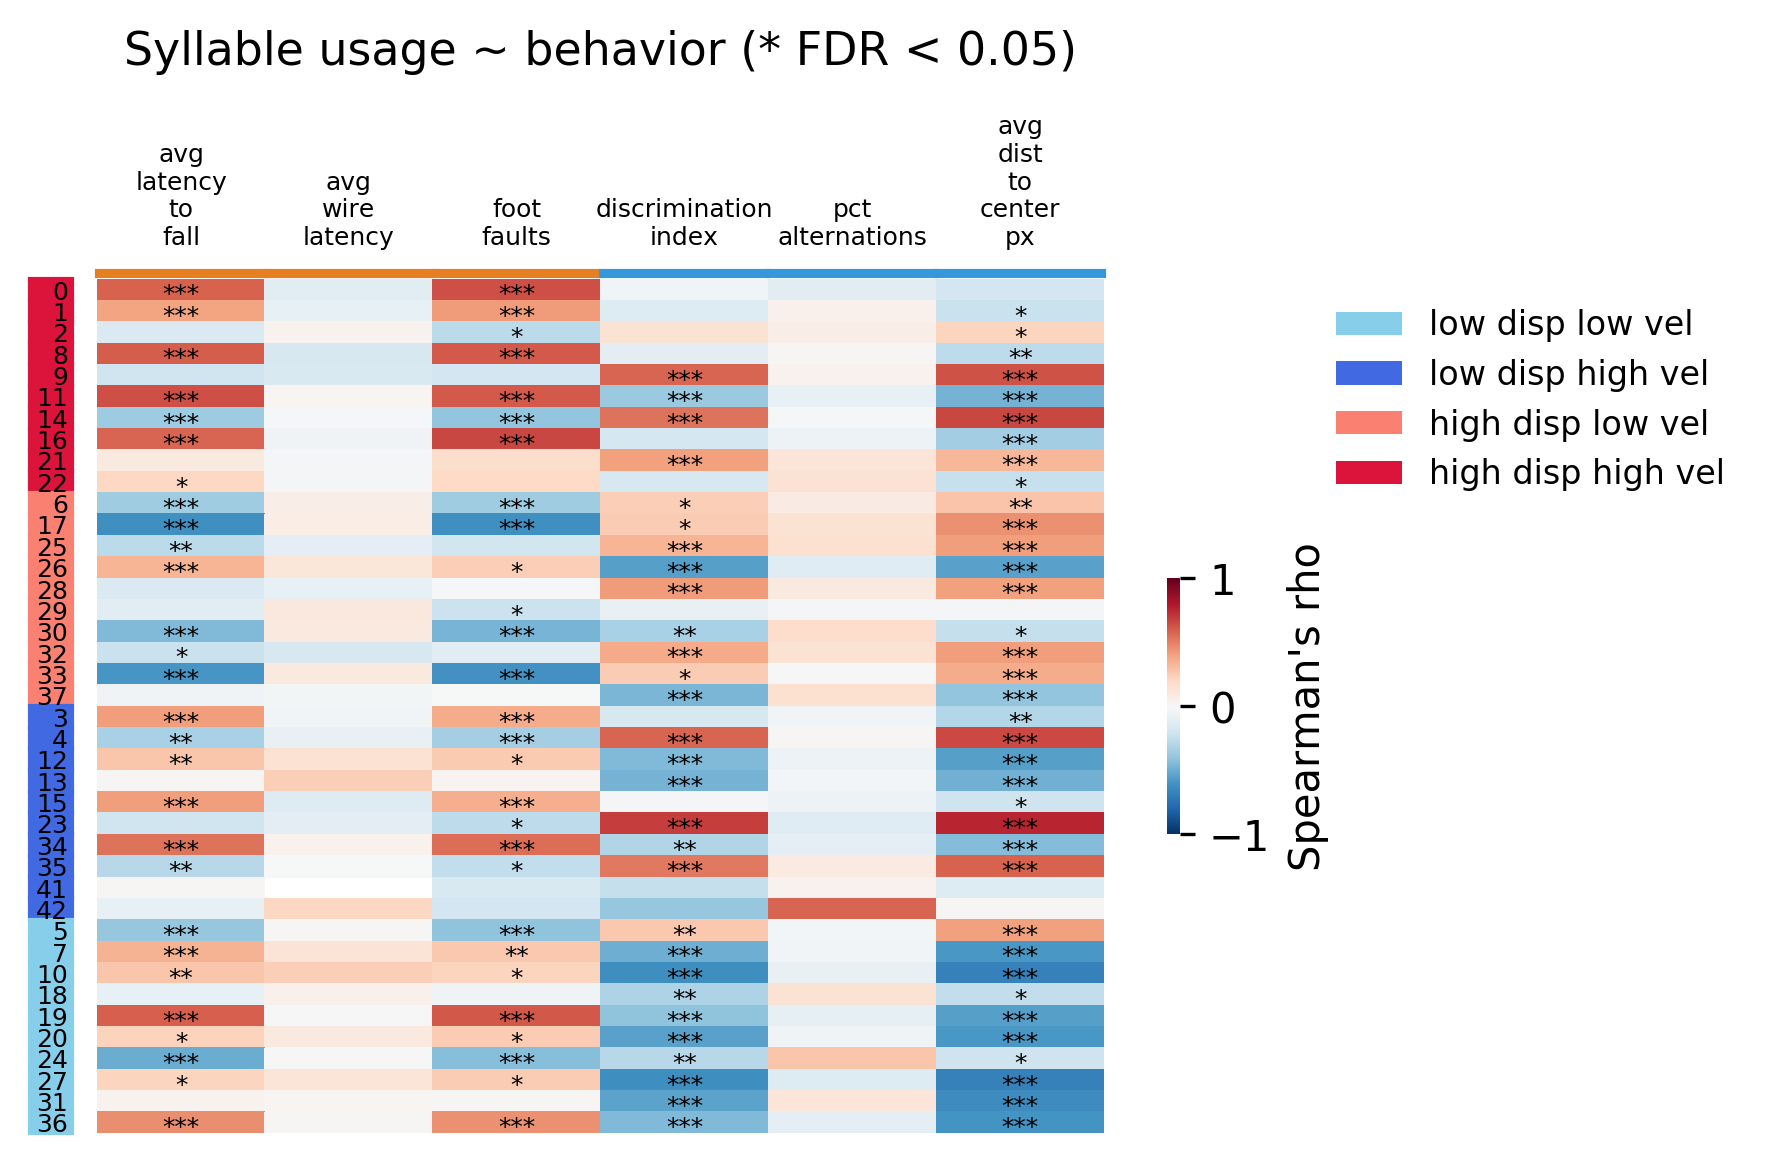

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

fig, ax = plt.subplots(dpi=300)

motor_tests     = ['avg_latency_to_fall', 'avg_wire_latency', 'foot_faults']
cognitive_tests = ['discrimination_index', 'pct_alternations', 'avg_dist_to_center_px']
col_order = motor_tests + cognitive_tests

rho_matrix = rho_matrix[col_order]
sig_matrix = sig_matrix[col_order]

metric_colors = {
    'avg_latency_to_fall':    '#e67e22',
    'avg_wire_latency':       '#e67e22',
    'foot_faults':            '#e67e22',
    'discrimination_index':   '#3498db',
    'pct_alternations':       '#3498db',
    'avg_dist_to_center_px':  '#3498db',
}

# Bottom strip — one patch per metric column
for j, metric in enumerate(rho_matrix.columns):
    ax.add_patch(plt.Rectangle(
        (j, -0.4), 1, 0.25,
        color=metric_colors[metric],
        clip_on=False, transform=ax.transData
    ))

# Left strip — cluster colors (already there)
for i, syl in enumerate(syllable_order):
    ax.add_patch(plt.Rectangle(
        (-0.4, i), 0.25, 1,
        color=cluster_colors[syllable_clusters[syl]],
        clip_on=False, transform=ax.transData
    ))

sns.heatmap(
    rho_matrix,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0,
    cbar_kws={'label': "Spearman's rho", 'shrink': 0.3},
    yticklabels=True,
    xticklabels=[c.replace('_', '\n') for c in rho_matrix.columns]
)

# Significance stars
for i, syl in enumerate(rho_matrix.index):
    for j, metric in enumerate(rho_matrix.columns):
        if sig_matrix.loc[syl, metric]:
            ax.text(j + 0.5, i + 0.75, '*',
                    ha='center', va='center',
                    fontsize=9, color='black')

# Minimal cluster strip
for i, syl in enumerate(syllable_order):
    ax.add_patch(plt.Rectangle(
        (-0.4, i), 0.25, 1,
        color=cluster_colors[syllable_clusters[syl]],
        clip_on=False, transform=ax.transData
    ))

ax.set_title("Syllable usage ~ behavior (* FDR < 0.05)", fontsize=11, pad=12)
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(left=False, bottom=False, labelsize=8)

# Minimal legend
legend_elements = [Patch(facecolor=v, label=k.replace('_', ' '))
                   for k, v in cluster_colors.items()]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.2, 1), loc='upper left',
          frameon=False, fontsize=8, title_fontsize=8)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('./syllable_behavior_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()

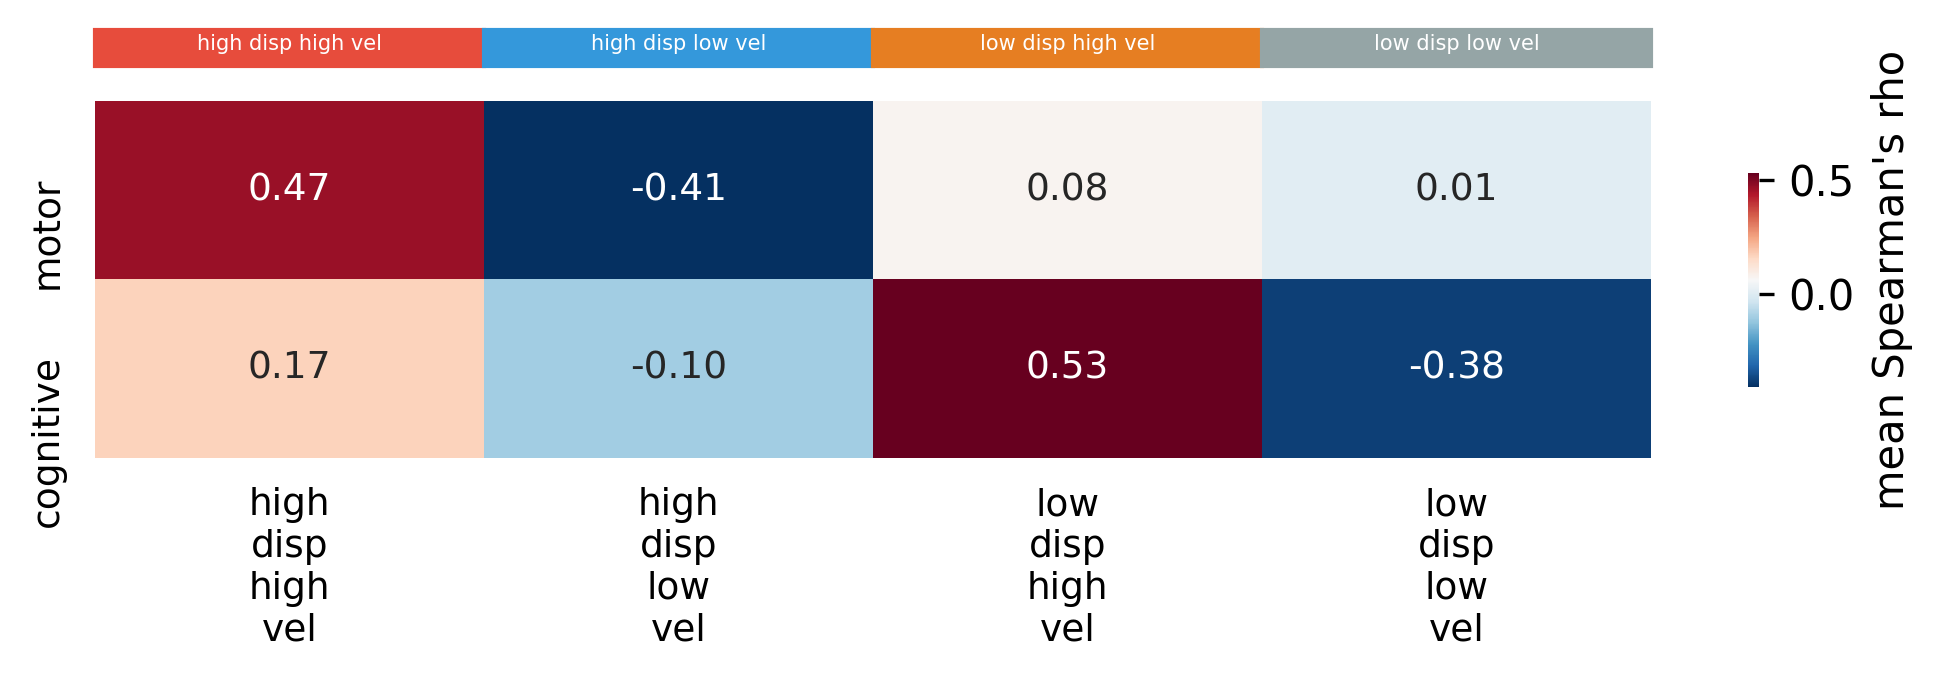

In [ ]:
col_order = ['high_disp_high_vel', 'high_disp_low_vel', 'low_disp_high_vel', 'low_disp_low_vel']
fig, ax = plt.subplots(figsize=(7, 2.5), dpi=300)

sns.heatmap(
    rho_matrix,
    ax=ax,
    cmap='RdBu_r',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    cbar_kws={'label': "mean Spearman's rho", 'shrink': 0.6},
    xticklabels=[c.replace('_', '\n') for c in col_order],
    yticklabels=rho_matrix.index.tolist()
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(left=False, bottom=False, labelsize=9)
#ax.set_title("Mean correlation by test type × syllable cluster", fontsize=11, pad=12)

# Bottom cluster type strip
disp_colors = {
    'high_disp_high_vel': '#e74c3c',
    'high_disp_low_vel':  '#3498db',
    'low_disp_high_vel':  '#e67e22',
    'low_disp_low_vel':   '#95a5a6'
}

for j, col in enumerate(col_order):
    ax.add_patch(plt.Rectangle(
        (j, -0.4), 1, 0.2,
        color=disp_colors[col],
        clip_on=False, transform=ax.transData
    ))
    ax.text(
        j + 0.5, -0.32,
        col.replace('_', ' '),
        ha='center', va='center',
        fontsize=5, color='white',
        clip_on=False, transform=ax.transData
    )
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('Correlation_Matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 7.2 Aggregate Correlation Matrix (Cluster × Metric)

Average Spearman ρ within each cluster × behavioral metric combination to produce a compact summary matrix. This collapses the per-syllable detail into a cluster-level view, making it easier to see whether entire behavioral clusters are systematically correlated with motor vs. cognitive assay performance.

In [ ]:
# ── Build usage_wide: one row per (mouse_id, timepoint), one col per cluster ──

# 1. Attach cluster label to each syllable's usage rows
usage_with_cluster = usage_df.merge(
    syllable_kinematics[['syllable', 'cluster']],
    on='syllable',
    how='inner'
)

# 2. Sum usage within each cluster, per mouse per timepoint
cluster_usage = (
    usage_with_cluster
    .groupby(['mouse_id', 'timepoint', 'cluster'])['usage']
    .sum()
    .reset_index()
)

# 3. Pivot: rows = (mouse_id, timepoint), cols = cluster
usage_wide = cluster_usage.pivot_table(
    index=['mouse_id', 'timepoint'],
    columns='cluster',
    values='usage',
    fill_value=0
).reset_index()

# Flatten column names
usage_wide.columns.name = None

# 4. Z-score each cluster column and add as z_usage_<cluster>
cluster_syllables = [c for c in usage_wide.columns if c not in ['mouse_id', 'timepoint']]

for cluster in cluster_syllables:
    col = usage_wide[cluster]
    usage_wide[f'z_usage_{cluster}'] = (col - col.mean()) / col.std()

print("usage_wide shape:", usage_wide.shape)
print("Columns:", usage_wide.columns.tolist())
display(usage_wide.head())

usage_wide shape: (105, 10)
Columns: ['mouse_id', 'timepoint', 'high_disp_high_vel', 'high_disp_low_vel', 'low_disp_high_vel', 'low_disp_low_vel', 'z_usage_high_disp_high_vel', 'z_usage_high_disp_low_vel', 'z_usage_low_disp_high_vel', 'z_usage_low_disp_low_vel']


,mouse_id,timepoint,high_disp_high_vel,high_disp_low_vel,low_disp_high_vel,low_disp_low_vel,z_usage_high_disp_high_vel,z_usage_high_disp_low_vel,z_usage_low_disp_high_vel,z_usage_low_disp_low_vel
0,VK_20251026_a,30DPI,0.243294,0.290367,0.208376,0.257963,-0.689119,0.345993,-0.922918,0.607848
1,VK_20251026_a,7DPI,0.246383,0.256370,0.223587,0.273660,-0.625919,-0.025163,-0.630941,0.798419
2,VK_20251026_a,BSL,0.208031,0.282200,0.263519,0.246250,-1.410632,0.256826,0.135553,0.465650
3,VK_20251026_aa,30DPI,0.313748,0.180747,0.234689,0.270816,0.752449,-0.850755,-0.417843,0.763889
4,VK_20251026_aa,7DPI,0.378553,0.159347,0.235727,0.226373,2.078413,-1.084384,-0.397912,0.224339


# 8. Cluster Usage per Animal

Aggregate syllable-level usage fractions up to the cluster level by summing usage across all syllables within each cluster, per animal per timepoint. Z-score each cluster's usage across animals to center and scale for downstream analyses (e.g., regression against behavioral scores).

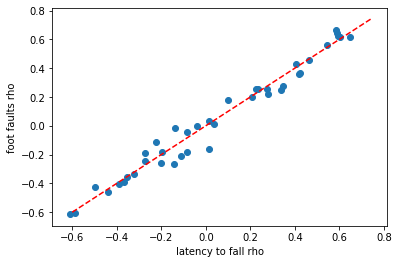

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(rho_matrix['avg_latency_to_fall'], rho_matrix['foot_faults'])
plt.xlabel('latency to fall rho')
plt.ylabel('foot faults rho')
limit = max(plt.xlim()[1], plt.ylim()[1])
plt.plot([-0.6, limit], [-0.6, limit], color='red', linestyle='--', label='identity')
plt.show()

## 7.3 Motor Assay Consistency Check

Scatter the per-cluster mean ρ for rotarod latency to fall against gridwalk foot faults to assess whether the two motor assays capture consistent signals. Points above the identity line indicate syllables more strongly correlated with gridwalk; points below indicate stronger rotarod correlation.

In [ ]:
corr_df.to_csv('CORRELATIONS.csv', index=False)